<h1>Modeling Train & Test perbagian</h1>

<h2>1. Setup & Load Data</h2>

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

In [2]:
PREPROCESS_DIR = "../data/processed/preprocessing"
MODEL_DIR = "../models"

X_train_path = os.path.join(PREPROCESS_DIR, "X_train_processed.csv")
X_test_path  = os.path.join(PREPROCESS_DIR, "X_test_processed.csv")
y_train_path = os.path.join(PREPROCESS_DIR, "y_train_encoded.csv")
y_test_path  = os.path.join(PREPROCESS_DIR, "y_test_encoded.csv")

print("X_train path:", X_train_path)
print("X_test  path:", X_test_path)
print("y_train path:", y_train_path)
print("y_test  path:", y_test_path)


X_train path: ../data/processed/preprocessing\X_train_processed.csv
X_test  path: ../data/processed/preprocessing\X_test_processed.csv
y_train path: ../data/processed/preprocessing\y_train_encoded.csv
y_test  path: ../data/processed/preprocessing\y_test_encoded.csv


In [3]:
# Load data
X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)

y_train = pd.read_csv(y_train_path).squeeze("columns")
y_test  = pd.read_csv(y_test_path).squeeze("columns")

print("\nLoaded shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nFeature columns:", list(X_train.columns))

print("\nLabel distribution (train):")
print(y_train.value_counts().sort_index())

print("\nLabel distribution (test):")
print(y_test.value_counts().sort_index())



Loaded shapes:
X_train: (6196, 6)
X_test : (1549, 6)
y_train: (6196,)
y_test : (1549,)

Feature columns: ['s5p_co', 's5p_no2', 's5p_o3', 's5p_so2', 'modis_MODIS_AOD_047', 'viirs_VIIRS_NTL']

Label distribution (train):
category
0    1566
1    2659
2    1971
Name: count, dtype: int64

Label distribution (test):
category
0    392
1    664
2    493
Name: count, dtype: int64


In [4]:
label_mapping = {"GOOD": 0, "MEDIUM": 1, "UNHEALTHY": 2}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

labels_order = sorted(inv_label_mapping.keys())
target_names = [inv_label_mapping[i] for i in labels_order]

print("labels_order:", labels_order)
print("target_names:", target_names)


labels_order: [0, 1, 2]
target_names: ['GOOD', 'MEDIUM', 'UNHEALTHY']


<h2>2. Train Test Models</h2>
<h4>2.1 Set up Models</h4>

In [5]:
def summary_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss"
    )
}

<h4>2.2 Training Data </h4>

In [7]:
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)   # TRAIN ONLY
    fitted_models[name] = model

print("All 4 models fitted on TRAIN.")


All 4 models fitted on TRAIN.


In [13]:
train_rows = []

for name, model in fitted_models.items():
    y_pred_train = model.predict(X_train)  # TRAIN PRED ONLY
    row = {"Model": name, **summary_metrics(y_train, y_pred_train)}
    train_rows.append(row)

train_table = (
    pd.DataFrame(train_rows)
      .set_index("Model")
      .sort_values("F1_macro", ascending=False)
      .round(4)
)

print("=== TRAIN EVALUATION TABLE (4 MODELS) ===")
display(train_table)


=== TRAIN EVALUATION TABLE (4 MODELS) ===


,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
Model,,,,,
Decision Tree,0.9935,0.9929,0.9937,0.9933,0.9935
Random Forest,0.9935,0.9936,0.9931,0.9933,0.9935
XGBoost,0.8699,0.8815,0.8568,0.8664,0.8694
Logistic Regression,0.4508,0.4384,0.3979,0.3832,0.4115


<h4>2.3 Linear Regression Testing</h4>

Classification Report (TEST) - Logistic Regression:
              precision    recall  f1-score   support

        GOOD     0.3698    0.1811    0.2432       392
      MEDIUM     0.4672    0.7500    0.5757       664
   UNHEALTHY     0.5189    0.3063    0.3852       493

    accuracy                         0.4648      1549
   macro avg     0.4520    0.4125    0.4014      1549
weighted avg     0.4590    0.4648    0.4309      1549

Confusion Matrix (TEST) - Logistic Regression:
[[ 71 275  46]
 [ 72 498  94]
 [ 49 293 151]]


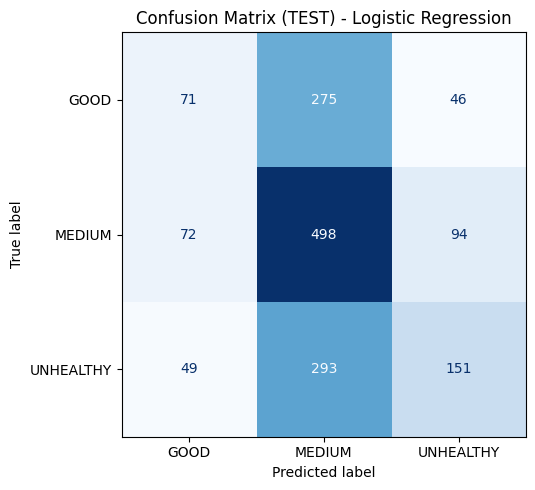

In [26]:
#Ambil model LR yang sudah di fit di train
lr_model = fitted_models["Logistic Regression"]

#Predict test
y_pred_test_lr = lr_model.predict(X_test)

#Classification Report test
print("Classification Report (TEST) - Logistic Regression:")
print(
    classification_report(
        y_test, y_pred_test_lr,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

#Confusion Matrix (CM)
cm_lr = confusion_matrix(y_test, y_pred_test_lr, labels=labels_order)
print("Confusion Matrix (TEST) - Logistic Regression:")
print(cm_lr)

# visual CM
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (TEST) - Logistic Regression")
plt.tight_layout()
plt.show()


<h4>2.4 Decision Tree Testing</h4>

Classification Report (TEST) - Decision Tree:
              precision    recall  f1-score   support

        GOOD     0.5026    0.5000    0.5013       392
      MEDIUM     0.5827    0.5783    0.5805       664
   UNHEALTHY     0.6280    0.6369    0.6324       493

    accuracy                         0.5771      1549
   macro avg     0.5711    0.5717    0.5714      1549
weighted avg     0.5768    0.5771    0.5770      1549

Confusion Matrix (TEST) - Decision Tree:
[[196 144  52]
 [146 384 134]
 [ 48 131 314]]


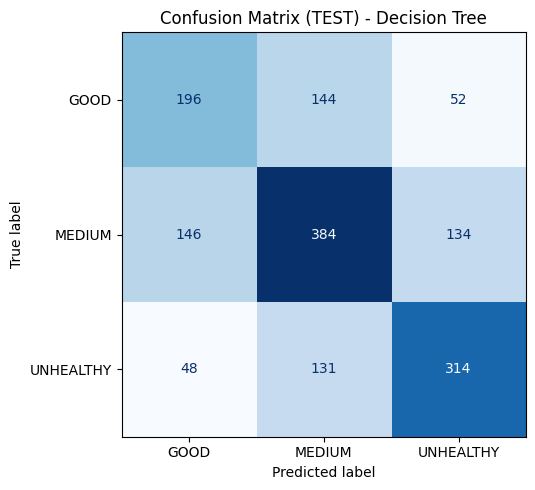

In [27]:
#ambil model Decision Tree yang sudah di fit di train
dt_model = fitted_models["Decision Tree"]

# Predict TEST
y_pred_test_dt = dt_model.predict(X_test)

#Classification Report
print("Classification Report (TEST) - Decision Tree:")
print(
    classification_report(
        y_test, y_pred_test_dt,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_test_dt, labels=labels_order)
print("Confusion Matrix (TEST) - Decision Tree:")
print(cm_dt)

#visual CM
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (TEST) - Decision Tree")
plt.tight_layout()
plt.show()


<h4>2.5 Random Forest Testing</h4>

Classification Report (TEST) - Random Forest:
              precision    recall  f1-score   support

        GOOD     0.6691    0.4592    0.5446       392
      MEDIUM     0.5949    0.7319    0.6563       664
   UNHEALTHY     0.6825    0.6410    0.6611       493

    accuracy                         0.6340      1549
   macro avg     0.6488    0.6107    0.6207      1549
weighted avg     0.6416    0.6340    0.6296      1549

Confusion Matrix (TEST) - Random Forest:
[[180 172  40]
 [ 71 486 107]
 [ 18 159 316]]


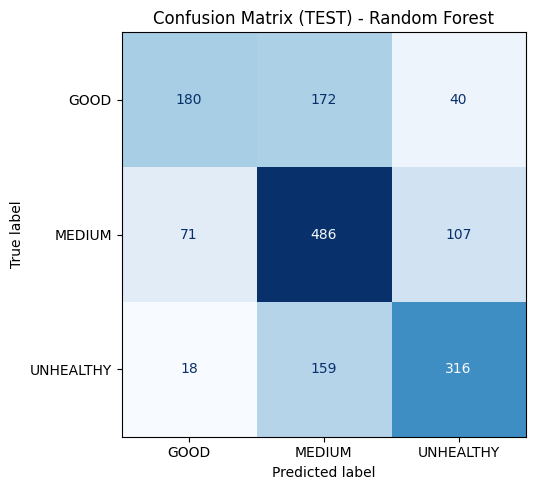

In [28]:
#Ambil model Random Forest yang sudah difit di train
rf_model = fitted_models["Random Forest"]

#Predict test
y_pred_test_rf = rf_model.predict(X_test)

#Classification Report 
print("Classification Report (TEST) - Random Forest:")
print(
    classification_report(
        y_test, y_pred_test_rf,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

#Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_test_rf, labels=labels_order)
print("Confusion Matrix (TEST) - Random Forest:")
print(cm_rf)

#Visual CM
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (TEST) - Random Forest")
plt.tight_layout()
plt.show()


<h4>2.6 XGBoost Testing</h4>

Classification Report (TEST) - XGBoost:
              precision    recall  f1-score   support

        GOOD     0.7345    0.5434    0.6246       392
      MEDIUM     0.6335    0.7575    0.6900       664
   UNHEALTHY     0.7118    0.6714    0.6910       493

    accuracy                         0.6759      1549
   macro avg     0.6933    0.6574    0.6685      1549
weighted avg     0.6840    0.6759    0.6738      1549

Confusion Matrix (TEST) - XGBoost:
[[213 147  32]
 [ 59 503 102]
 [ 18 144 331]]


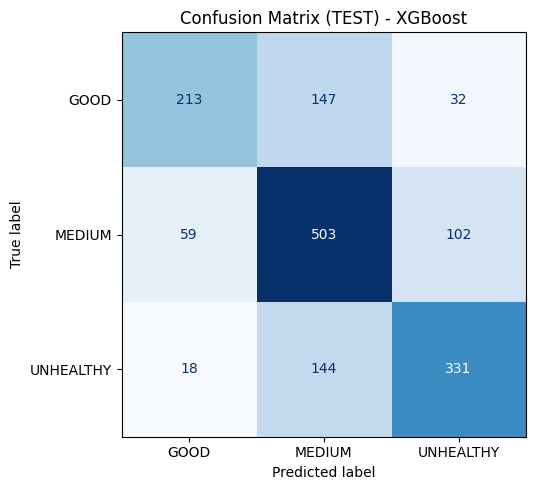

In [29]:
#ambil model XGBoost yang sudah difit di train
xgb_model = fitted_models["XGBoost"]

#predict test
y_pred_test_xgb = xgb_model.predict(X_test)

#Classification Report
print("Classification Report (TEST) - XGBoost:")
print(
    classification_report(
        y_test, y_pred_test_xgb,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

#Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_test_xgb, labels=labels_order)
print("Confusion Matrix (TEST) - XGBoost:")
print(cm_xgb)

# visual CM
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (TEST) - XGBoost")
plt.tight_layout()
plt.show()


<h2>3. Comparison Model</h2>

In [15]:
#membuat perbandingan antar model
comparison_rows = []

for name, model in fitted_models.items():
    y_pred_test = model.predict(X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_test),
        "Precision_macro": precision_score(y_test, y_pred_test, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred_test, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred_test, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred_test, average="weighted", zero_division=0),
    }

    comparison_rows.append(row)

#buat tabel comparison
comparison_table = (
    pd.DataFrame(comparison_rows)
      .set_index("Model")
      .sort_values("F1_macro", ascending=False)
      .round(4)
)

print("=== MODEL COMPARISON (TEST) ===")
display(comparison_table)


=== MODEL COMPARISON (TEST) ===


,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
Model,,,,,
XGBoost,0.6759,0.6933,0.6574,0.6685,0.6738
Random Forest,0.6340,0.6488,0.6107,0.6207,0.6296
Decision Tree,0.5771,0.5711,0.5717,0.5714,0.5770
Logistic Regression,0.4648,0.4520,0.4125,0.4014,0.4309


In [16]:
best_model_name = comparison_table.index[0]
best_model_name


'XGBoost'

<h4>3.1 Hyperparameter Tuning Best Model</h4>

In [30]:
if best_model_name == "XGBoost":
    base_estimator = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )

    param_distributions = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0, 0.1, 0.2, 0.5]
    }

    search = RandomizedSearchCV(
        estimator=base_estimator,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="f1_macro",
        cv=5,
        random_state=42,
        verbose=1,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV score (F1-macro):")
    print(search.best_score_)
else:
    raise ValueError(f"Best model adalah '{best_model_name}'")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.7}

Best CV score (F1-macro):
0.6695945111215157


In [19]:
print("Best parameters:")
print(search.best_params_)

print("\nBest CV score (F1-macro):")
print(search.best_score_)


Best parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.7}

Best CV score (F1-macro):
0.6695945111215157


<h4>3.2 Predict Test (tuned model)</h4>

In [20]:
best_tuned_model = search.best_estimator_
best_tuned_model


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [21]:
y_pred_test_tuned = best_tuned_model.predict(X_test)


Classification Report (TEST) - Tuned XGBoost:
              precision    recall  f1-score   support

        GOOD     0.7177    0.5383    0.6152       392
      MEDIUM     0.6326    0.7545    0.6882       664
   UNHEALTHY     0.7171    0.6734    0.6946       493

    accuracy                         0.6740      1549
   macro avg     0.6891    0.6554    0.6660      1549
weighted avg     0.6810    0.6740    0.6717      1549


Confusion Matrix (TEST) - Tuned Model:
[[211 148  33]
 [ 65 501  98]
 [ 18 143 332]]


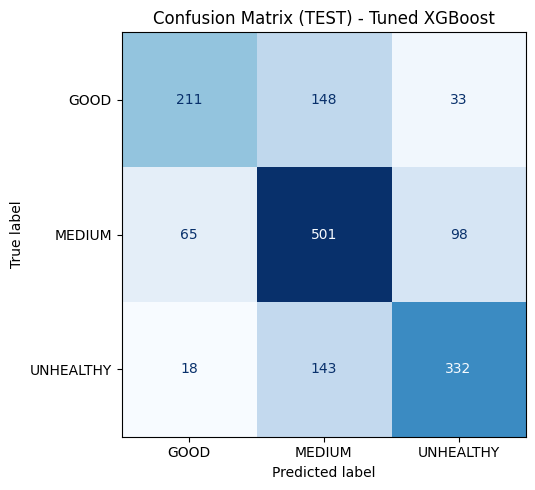

In [22]:
print(f"Classification Report (TEST) - Tuned {best_model_name}:")
print(
    classification_report(
        y_test, y_pred_test_tuned,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

cm_tuned = confusion_matrix(y_test, y_pred_test_tuned, labels=labels_order)
print("\nConfusion Matrix (TEST) - Tuned Model:")
print(cm_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Confusion Matrix (TEST) - Tuned {best_model_name}")
plt.tight_layout()
plt.show()


In [23]:
tuned_summary = pd.DataFrame(
    [{"Model": f"Tuned {best_model_name}", **summary_metrics(y_test, y_pred_test_tuned)}]
).set_index("Model").round(4)

print("=== Tuned Model Summary (TEST) ===")
display(tuned_summary)


=== Tuned Model Summary (TEST) ===


,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
Model,,,,,
Tuned XGBoost,0.674,0.6891,0.6554,0.666,0.6717


<h4>3.3 Save Best Model</h4>

In [24]:
# save model

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok = True)

best_model_path = os.path.join(MODEL_DIR, "xgb_model_test.pkl")

joblib.dump(xgb_model, best_model_path)
print(f"Best Model Save di : {best_model_path}")

Best Model Save di : ../models\xgb_model_test.pkl
